In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nestle-india-historical-stock-price-data/nestle.csv


In [2]:
df = pd.read_csv('/kaggle/input/nestle-india-historical-stock-price-data/nestle.csv',parse_dates = ['Date'])

In [3]:
df.head()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
0,2022-04-21,18150.00,18572.95,17772.90,18205.80,18130.183442,4590,1770,83217542.0,950.0,20.70,800.05,55.80
1,2022-04-20,18100.10,18415.00,18017.15,18313.70,18295.559071,6069,1321,111035748.0,4677.0,77.06,397.85,213.60
2,2022-04-19,18470.05,18718.00,17845.60,17943.15,18355.093320,2904,716,53303191.0,1619.0,55.75,872.40,-526.90
3,2022-04-18,18294.50,18684.50,18294.50,18549.85,18511.224599,1496,586,27692792.0,557.0,37.23,390.00,255.35
4,2022-04-13,18371.20,18549.30,18248.25,18343.90,18388.967826,1150,550,21147313.0,573.0,49.83,301.05,-27.30


In [4]:
df.shape

(2553, 13)

In [5]:
df.describe()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open
count,2553,2553.000000,2553.000000,2553.000000,2553.000000,2553.000000,2553.000000,2553.000000,2.553000e+03,2551.000000,2551.000000,2553.000000,2553.000000
mean,2017-02-22 02:05:46.886016256,9338.023188,9429.710419,9226.855934,9324.960556,9327.503179,5521.380337,1004.099491,4.761923e+07,3264.052528,49.024461,202.854485,-13.062632
min,2012-01-02 00:00:00,3970.000000,3995.000000,3930.000000,3942.450000,3936.768632,39.000000,6.000000,1.721420e+05,33.000000,1.270000,17.000000,-1381.300000
25%,2014-07-21 00:00:00,5391.000000,5445.000000,5327.200000,5383.500000,5385.347807,1572.000000,442.000000,1.172133e+07,653.500000,35.575000,88.850000,-71.700000
50%,2017-02-22 00:00:00,6804.000000,6868.900000,6747.300000,6809.950000,6813.150538,2618.000000,731.000000,2.222074e+07,1123.000000,46.870000,152.100000,-12.750000
75%,2019-09-25 00:00:00,13299.950000,13690.950000,12850.000000,13455.450000,13387.505382,4981.000000,1199.000000,4.938465e+07,2225.500000,59.130000,263.150000,48.300000
max,2022-04-21 00:00:00,20452.000000,20599.950000,20243.800000,20439.450000,20417.372402,154684.000000,20964.000000,2.155655e+09,152993.000000,98.930000,1950.000000,1523.300000
std,NaN,4940.554627,4986.783271,4878.971233,4932.776537,4929.373727,10416.942384,1137.547557,8.502888e+07,8652.860793,19.119739,174.985173,157.849187


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553 entries, 0 to 2552
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       2553 non-null   datetime64[ns]
 1   Open Price                 2553 non-null   float64       
 2   High Price                 2553 non-null   float64       
 3   Low Price                  2553 non-null   float64       
 4   Close Price                2553 non-null   float64       
 5   WAP                        2553 non-null   float64       
 6   No.of Shares               2553 non-null   int64         
 7   No. of Trades              2553 non-null   int64         
 8   Total Turnover (Rs.)       2553 non-null   float64       
 9   Deliverable Quantity       2551 non-null   float64       
 10  % Deli. Qty to Traded Qty  2551 non-null   float64       
 11  Spread High-Low            2553 non-null   float64       
 12  Spread

In [7]:
df.isnull().sum()

Date                         0
Open Price                   0
High Price                   0
Low Price                    0
Close Price                  0
WAP                          0
No.of Shares                 0
No. of Trades                0
Total Turnover (Rs.)         0
Deliverable Quantity         2
% Deli. Qty to Traded Qty    2
Spread High-Low              0
Spread Close-Open            0
dtype: int64

In [8]:
median_val = round(df['Deliverable Quantity'].median())
df['Deliverable Quantity'] = df['Deliverable Quantity'].fillna(median_val)

In [9]:
median_val2 = round(df['% Deli. Qty to Traded Qty'].median())
df['% Deli. Qty to Traded Qty'] = df['% Deli. Qty to Traded Qty'].fillna(median_val2)

In [10]:
df.columns
df = df.sort_values('Date') #sort Dates


> ROI Formula :-
ROI = (Final Value - Initial Investment/Initial Investment) * 100
**> for Stock Price Data :-
ROI = (Close Price end - Open price start/Open price start) * 100

In [11]:
# Now Calculating ROI over the full period
intial_price = df.iloc[0]['Open Price']
final_price = df.iloc[-1]['Close Price']

In [12]:
ROI = ((final_price - intial_price) / intial_price) * 100
print(f"Total ROI from {df.iloc[0]['Date'].date()} to {df.iloc[-1]['Date'].date()}: {ROI:.2f}%")

Total ROI from 2012-01-02 to 2022-04-21: 339.76%


# Total ROI from 2012-01-02 to 2022-04-21: 0.90%

In [13]:
df['Month'] = df['Date'].dt.to_period("M")

monthly_roi = df.groupby("Month").apply(
    lambda x: ((x.iloc[-1]['Close Price'] - x.iloc[0]['Open Price']) / x.iloc[0]['Open Price']) * 100
)

/tmp/ipykernel_13/1076018066.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_roi = df.groupby("Month").apply(


In [14]:
print(monthly_roi.head())

Month
2012-01    2.652238
2012-02    3.967105
2012-03    4.136878
2012-04    3.072358
2012-05   -3.853789
Freq: M, dtype: float64


In [15]:
#converting monthly roi to df 
monthly_roi_df = monthly_roi.reset_index()
monthly_roi_df.columns = ['Month', 'Monthly ROI (%)']

In [16]:
#Merge the ROI back into the original DataFrame
df = df.merge(monthly_roi_df, on='Month', how='left')

In [17]:
df.head()

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open,Month,Monthly ROI (%)
0,2012-01-02,4139.9,4139.9,4044.0,4070.35,4085.640979,7760,1132,31704574.0,5776.0,74.43,95.9,-69.55,2012-01,2.652238
1,2012-01-03,4061.0,4110.1,4060.1,4095.35,4091.474315,5003,886,20469646.0,2817.0,56.31,50.0,34.35,2012-01,2.652238
2,2012-01-04,4100.0,4125.0,4081.4,4120.60,4105.106055,2857,247,11728288.0,2312.0,80.92,43.6,20.60,2012-01,2.652238
3,2012-01-05,4118.0,4126.9,4080.0,4101.85,4106.848723,1018,270,4180772.0,357.0,35.07,46.9,-16.15,2012-01,2.652238
4,2012-01-06,4114.0,4160.0,4076.0,4143.25,4129.486321,3107,444,12830314.0,2069.0,66.59,84.0,29.25,2012-01,2.652238


In [18]:
df['Years'] = df['Date'].dt.to_period("Y")

yearly_roi = df.groupby("Years").apply(
    lambda x: ((x.iloc[-1]['Close Price'] - x.iloc[0]['Open Price']) / x.iloc[0]['Open Price']) * 100
)

/tmp/ipykernel_13/209241507.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_roi = df.groupby("Years").apply(


In [19]:
#converting Yesrly roi to df 
yearly_roi_df = yearly_roi.reset_index()
yearly_roi_df.columns = ['Years', 'yearly ROI (%)']

In [20]:
df = df.merge(yearly_roi_df, on='Years', how='left')

In [21]:
df.head(5)

,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open,Month,Monthly ROI (%),Years,yearly ROI (%)
0,2012-01-02,4139.9,4139.9,4044.0,4070.35,4085.640979,7760,1132,31704574.0,5776.0,74.43,95.9,-69.55,2012-01,2.652238,2012,20.543974
1,2012-01-03,4061.0,4110.1,4060.1,4095.35,4091.474315,5003,886,20469646.0,2817.0,56.31,50.0,34.35,2012-01,2.652238,2012,20.543974
2,2012-01-04,4100.0,4125.0,4081.4,4120.60,4105.106055,2857,247,11728288.0,2312.0,80.92,43.6,20.60,2012-01,2.652238,2012,20.543974
3,2012-01-05,4118.0,4126.9,4080.0,4101.85,4106.848723,1018,270,4180772.0,357.0,35.07,46.9,-16.15,2012-01,2.652238,2012,20.543974
4,2012-01-06,4114.0,4160.0,4076.0,4143.25,4129.486321,3107,444,12830314.0,2069.0,66.59,84.0,29.25,2012-01,2.652238,2012,20.543974


In [22]:
import matplotlib.pyplot as plt 
import seaborn as sns

 # df['20D MA'] = df['Close Price'].rolling(window=20).mean()
- df['Close Price']: This is the column with daily closing prices of Nestlé India stock.
- .rolling(window=20): Creates a rolling window of 20 days.
- .mean(): Calculates the average closing price over each 20-day window.
- Result: A new column '20D MA' (20-Day Moving Average) is added to your DataFrame.
👉 This smooths out short-term fluctuations and highlights longer-term trends.
 df[['Date', 'Close Price', '20D MA']].plot(x='Date', figsize=(12, 6))
- df[['Date', 'Close Price', '20D MA']]: Selects the date, actual closing price, and moving average for plotting.
- .plot(x='Date'): Uses 'Date' as the x-axis.
- figsize=(12, 6): Sets the plot size to 12 inches wide and 6 inches tall.
👉 This generates a line chart showing:
- The actual daily closing price (more jagged)
- The 20-day moving average (smoother line)
- - Blue line: Daily 'Close Price' — shows volatility
- Orange line: '20D MA' — shows trend direction
🧠 Why It’s Useful
- Helps identify bullish or bearish trends
- Can be used for crossover strategies (e.g., when price crosses above MA → buy signal)



<Axes: xlabel='Date'>

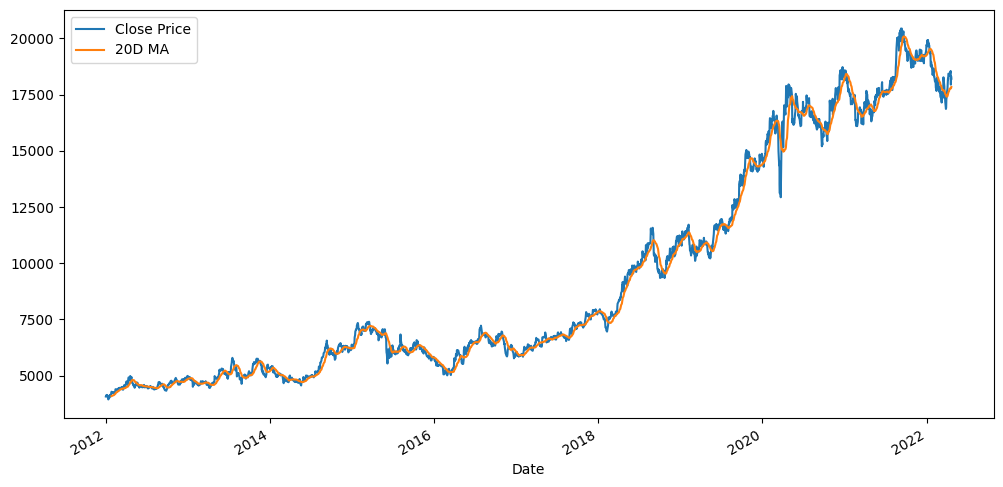

In [23]:
df['20D MA'] = df['Close Price'].rolling(window=20).mean()
df[['Date', 'Close Price', '20D MA']].plot(x='Date', figsize=(12, 6))

3. Volume and Liquidity Analysis
Use: 'No.of Shares', 'No. of Trades', 'Deliverable Quantity', '% Deli. Qty to Traded Qty'
What to do:
- Track changes in trading volume
- Analyze delivery percentage to assess investor confidence
- Identify spikes in trades vs. price movement

In [24]:
df['Delivery Ratio'] = df['Deliverable Quantity'] / df['No.of Shares']

<Axes: xlabel='Date'>

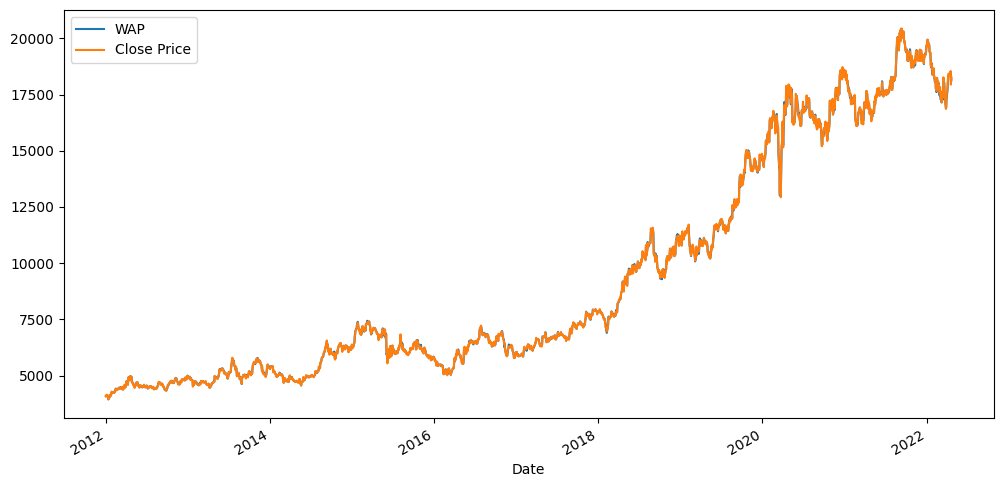

In [25]:
df[['Date', 'WAP', 'Close Price']].plot(x='Date', figsize=(12, 6))

4. Turnover and Weighted Average Price (WAP)
Use: 'Total Turnover (Rs.)', 'WAP'
What to do:
- Compare WAP to actual closing prices
- Analyze turnover trends to spot high-activity days
- Correlate turnover with ROI and volatility


In [26]:
df['Daily ROI (%)'] = ((df['Close Price'] - df['Open Price']) / df['Open Price']) * 100

In [27]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_summary = df.groupby('Month').agg({
    'Daily ROI (%)': 'mean',
    'No.of Shares': 'sum',
    'Total Turnover (Rs.)': 'sum'
})

5. Time-Based Grouping
Use: 'Date' → extract 'Month', 'Year'
What to do:
- Group by month/year to calculate average ROI, volume, volatility
- Compare performance across fiscal years
- Identify seasonal patterns or anomalies


In [28]:
df.columns = df.columns.str.strip()

In [29]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Date,Open Price,High Price,Low Price,Close Price,WAP,No.of Shares,No. of Trades,Total Turnover (Rs.),Deliverable Quantity,% Deli. Qty to Traded Qty,Spread High-Low,Spread Close-Open,Month,Monthly ROI (%),Years,yearly ROI (%),20D MA,Delivery Ratio,Daily ROI (%)
0,2012-01-02,4139.9,4139.9,4044.0,4070.35,4085.640979,7760,1132,31704574.0,5776.0,74.43,95.9,-69.55,2012-01,2.652238,2012,20.543974,NaN,0.744330,-1.679992
1,2012-01-03,4061.0,4110.1,4060.1,4095.35,4091.474315,5003,886,20469646.0,2817.0,56.31,50.0,34.35,2012-01,2.652238,2012,20.543974,NaN,0.563062,0.845851
2,2012-01-04,4100.0,4125.0,4081.4,4120.60,4105.106055,2857,247,11728288.0,2312.0,80.92,43.6,20.60,2012-01,2.652238,2012,20.543974,NaN,0.809240,0.502439
3,2012-01-05,4118.0,4126.9,4080.0,4101.85,4106.848723,1018,270,4180772.0,357.0,35.07,46.9,-16.15,2012-01,2.652238,2012,20.543974,NaN,0.350688,-0.392181
4,2012-01-06,4114.0,4160.0,4076.0,4143.25,4129.486321,3107,444,12830314.0,2069.0,66.59,84.0,29.25,2012-01,2.652238,2012,20.543974,NaN,0.665916,0.710987


In [30]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna()


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [32]:
features = [
    'Open Price', 'High Price', 'Low Price', 'WAP',
    'No.of Shares', 'No. of Trades', 'Total Turnover (Rs.)',
    'Deliverable Quantity', 'Spread High-Low', 'Spread Close-Open',
    '20D MA', 'Delivery Ratio'
]

# Define target (dependent variable)
target = 'Close Price'

X = df[features]
y = df[target]


In [33]:
df.columns


Index(['Date', 'Open Price', 'High Price', 'Low Price', 'Close Price', 'WAP',
       'No.of Shares', 'No. of Trades', 'Total Turnover (Rs.)',
       'Deliverable Quantity', '% Deli. Qty to Traded Qty', 'Spread High-Low',
       'Spread Close-Open', 'Month', 'Monthly ROI (%)', 'Years',
       'yearly ROI (%)', '20D MA', 'Delivery Ratio', 'Daily ROI (%)'],
      dtype='object')

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R² Score: 1.0
RMSE: 2.8639549778302448e-11


In [37]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

In [38]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

MSE: 702.07


In [39]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
ridge_cv.fit(X_train, y_train)
print(f"Best alpha: {ridge_cv.alpha_}")

Best alpha: 0.1


In [40]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])
lasso.fit(X_train, y_train)
print(f"Lasso MSE: {mean_squared_error(y_test, lasso.predict(X_test)):.2f}")

Lasso MSE: 1.91


In [41]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridgecv', RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]))
])
model.fit(X_train, y_train)
print("Best alpha:", model.named_steps['ridgecv'].alpha_)

Best alpha: 0.1


In [42]:
lasso_coef = pd.Series(model.named_steps['ridgecv'].coef_, index=model.named_steps['poly'].get_feature_names_out(X.columns))
print(lasso_coef.sort_values())

WAP^2                   -205.348901
Low Price WAP           -192.691754
High Price WAP          -191.248063
Low Price^2             -179.030245
High Price Low Price    -178.529832
                           ...     
Open Price^2             630.194824
High Price               935.563068
Low Price                955.963694
WAP                      980.595125
Open Price              1796.391982
Length: 91, dtype: float64


In [43]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic_cv', ElasticNetCV(alphas=[0.1, 1.0, 10.0], l1_ratio=[0.1, 0.5, 0.9], cv=5))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Tuned ElasticNet MSE: {mean_squared_error(y_test, y_pred):.2f}")

Tuned ElasticNet MSE: 2955.61


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error
import pandas as pd

def train_elasticnet_pipeline(X, y, alphas=[0.1, 1.0, 10.0], l1_ratios=[0.1, 0.5, 0.9], cv=5):
    """
    Trains an ElasticNet pipeline with scaling and cross-validation.
    Returns the trained model and MSE on a holdout set.
    """
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('elastic_cv', ElasticNetCV(alphas=alphas, l1_ratio=l1_ratios, cv=cv))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    print(f"Best alpha: {pipeline.named_steps['elastic_cv'].alpha_}")
    print(f"Best l1_ratio: {pipeline.named_steps['elastic_cv'].l1_ratio_}")
    print(f"Test MSE: {mse:.2f}")
    
    return pipeline

In [45]:
def predict_new_data(model, X,y):
    """
    Accepts a trained pipeline and new data (as DataFrame).
    Returns predictions as a DataFrame.
    """
    preds = model.predict(X,y)
    return pd.DataFrame({'prediction': preds})

In [46]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 77.1 MB/s eta 0:00:00


In [47]:
import streamlit as st

st.title("ElasticNet Predictor")
uploaded_file = st.file_uploader("Upload CSV", type="csv")

if uploaded_file:
    new_data = pd.read_csv(uploaded_file)
    preds = predict_new_data(trained_model, new_data)
    st.write(preds)

2025-11-03 15:43:35.108 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.295 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-11-03 15:43:35.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-03 15:43:35.299 Thread 'MainThread': mi

In [48]:
import os
print(os.listdir())  # Lists files in the current directory

['__notebook__.ipynb']


In [49]:
model = train_elasticnet_pipeline(X, y)

Best alpha: 0.1
Best l1_ratio: 0.9
Test MSE: 2955.61


In [50]:
df.columns

Index(['Date', 'Open Price', 'High Price', 'Low Price', 'Close Price', 'WAP',
       'No.of Shares', 'No. of Trades', 'Total Turnover (Rs.)',
       'Deliverable Quantity', '% Deli. Qty to Traded Qty', 'Spread High-Low',
       'Spread Close-Open', 'Month', 'Monthly ROI (%)', 'Years',
       'yearly ROI (%)', '20D MA', 'Delivery Ratio', 'Daily ROI (%)'],
      dtype='object')

In [51]:
X = df[features]
y = df[target]

In [52]:
X = X.select_dtypes(exclude=['datetime'])

model = train_elasticnet_pipeline(X, y)

Best alpha: 0.1
Best l1_ratio: 0.9
Test MSE: 2955.61


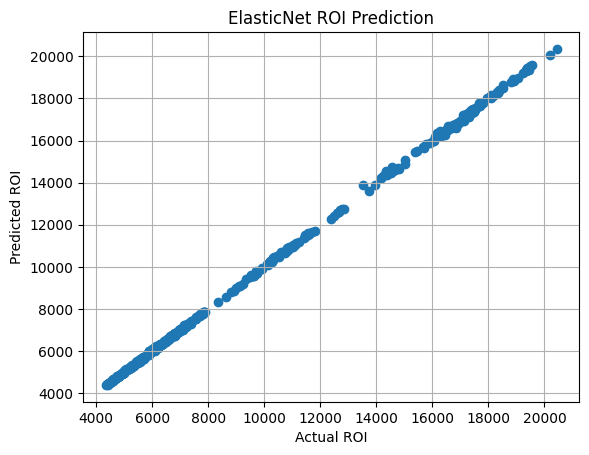

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test, model.predict(X_test))
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.title("ElasticNet ROI Prediction")
plt.grid(True)
plt.show()

In [54]:
preds_df = pd.DataFrame({
    "Date": df.loc[X_test.index, "Date"],
    "Actual ROI": y_test,
    "Predicted ROI": model.predict(X_test)
})
preds_df.to_csv("elasticnet_roi_predictions.csv", index=False)